In [1]:
import watershed
import py21cmfast as p21c # To run 21cmFirstCLASS (21cmFAST)
import matplotlib.pyplot as plt
import matplotlib as mpl


import numpy as np 

plt.rcParams.update({"text.usetex": True, "font.family": "Times new roman"}) # Use latex fonts
colors =  ['#377eb8', '#ff7f00', '#4daf4a',
           '#f781bf', '#a65628', '#984ea3',
           '#999999', '#e41a1c', '#dede00']

mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=colors) # Set the color palette as default


-----------------------------------------------------
SarahLibanore: developed f_nl in IC and fcoll, fixed on 05/10/2026
-----------------------------------------------------


In [2]:
def run_sim(Lbox, Nbox, fnl, force_mmax, write_flag):

    try:

        flag_options = {"USE_MINI_HALOS": False, } # if False, popIII stars are not included - Note: if set to True, the runtime increases significantly!

        astro_params = {"F_STAR10": -1.25, # star formation efficiency (atomic cooling galaxies) for pivot mass 1e10 Msun (log10)
                        "ALPHA_STAR": 0.5, # slope of the dependency of star formation efficiency on the host halo mass 
                        "F_ESC10": -1.35, # escape fraction of Lyman photons into the IGM for pivot mass 1e10 Msun (log10)
                        "ALPHA_ESC": 0., # slope of the dependency of escape fraction on the host halo mass 
                        "L_X": 40.5, # X-ray luminosity (log10)
        }

        global_quantities = ("brightness_temp", # brightness temperature
                            "xH_box") # free electron fraction

        coeval_quantities = ["density", # matter density fluctuations 
                            "xH_box",
                            "brightness_temp"]

        input_coeval_redshifts = [7.,9.,11.,12.,15.]

        lightcone_quantities = ("brightness_temp",)

        user_params = {"BOX_LEN": Lbox, # size of the simulated box (in comoving Mpc) 
                    "HII_DIM": Nbox, # number of cells along each axis of the coeval box - Note: more cells means longer runtime! 
                    "EXTRA_DIM_FNL":1.,
                    "N_THREADS": 6, # the amount of processors the code uses in parallelization
                    "NON_GAUSS_IC":False if fnl == 0. else True, # use non gaussian field in initial conditions
                    "NON_GAUSS_FCOLL":False if fnl == 0. else True,# use non gaussian field in collapsed fraction
                    "NG_MODEL_APPROX":False,
                    "FULL_ION_SIMPLE":True,
                    "FORCE_MMAX": force_mmax,
                    "WRITE_CGF_DIAG":write_flag, 
                    } # 

        cosmo_params = {"hlittle": 0.6736, # hubble parameter
                        "OMb": 0.0493, # baryon density
                        "OMm": 0.3153, # matter (CDM+baryon) density
                        "A_s": 2.1e-9, # amplitude of the primordial fluctuations
                        "POWER_INDEX": 0.9649, # spectral index of the primordial spectrum
                        "tau_reio": 0.0544, # optical depth to reionization
                        "F_NL":fnl, # to test matching with old case
                        }

        lightcone = p21c.run_lightcone(redshift = 6., # minimum redshift at which the simulation will stop
                                    random_seed = 1, # numerical seed -- if None, each run will produce different initial conditions, with the same cosmological power spectrum but different spatial realization. You need to specify the random seed to coherently compare two different runs, due to cosmic variance. 
                                    regenerate = True, # create new data even if cached are found
                                    write = False, # whether or no to save cached files
                                    user_params = user_params,
                                    astro_params = astro_params, 
                                    flag_options = flag_options,
                                    cosmo_params = cosmo_params,
                                    global_quantities = global_quantities,
                                    save_coeval_quantities = coeval_quantities,
                                    save_coeval_redshifts = input_coeval_redshifts,
                                    lightcone_quantities = lightcone_quantities) ; 
    except:
        print('\n FAILED!')
        print(str(Lbox) + '_' + str(Nbox) + '_' + str(fnl) + '_' + str(force_mmax) + '_' + str(write_flag))
        print('/n')

        lightcone = -1

    return lightcone


In [3]:
cut_mass = 12.

In [40]:
fnl0_original = run_sim(30, 10, 0., 0., False)

Now running CLASS...
Now generating initial boxes...


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [00:47<00:00,  1.77redshift/s]


Now evaluating tau to reionization and re-running CLASS...


In [4]:
fnl0 = run_sim(100, 25, 0., cut_mass, False)

Now running CLASS...
Now generating initial boxes...


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [01:11<00:00,  1.17redshift/s]


Now evaluating tau to reionization and re-running CLASS...


In [6]:
fnl200 = run_sim(100, 25, 200., cut_mass, False)

Now running CLASS...
Computing three point functions to estimate the Fcoll NG corrections...
Now generating initial boxes...


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [03:16<00:00,  2.34s/redshift]


Now evaluating tau to reionization and re-running CLASS...


In [ ]:
fnlm200 = run_sim(100, 25, -200., cut_mass, False)

Now running CLASS...


In [ ]:
fnl10 = run_sim(30, 10, 10., cut_mass, False) # already saved


Now running CLASS...
Computing three point functions to estimate the Fcoll NG corrections...
Now generating initial boxes...


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [02:56<00:00,  2.10s/redshift]


Now evaluating tau to reionization and re-running CLASS...


In [ ]:
fnlm10 = run_sim(30, 10, -10., cut_mass, False) # already saved


Now running CLASS...
Computing three point functions to estimate the Fcoll NG corrections...
Now generating initial boxes...


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [03:33<00:00,  2.54s/redshift]


Now evaluating tau to reionization and re-running CLASS...


In [5]:
fnl50 = run_sim(50, 50, 50., cut_mass, False) # already saved

Now running CLASS...
Computing three point functions to estimate the Fcoll NG corrections...
Now generating initial boxes...


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [04:27<00:00,  3.18s/redshift]


Now evaluating tau to reionization and re-running CLASS...


In [6]:
fnlm50 = run_sim(50, 50, -50., cut_mass, False) # already saved

Now running CLASS...
Computing three point functions to estimate the Fcoll NG corrections...
Now generating initial boxes...


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [05:05<00:00,  3.63s/redshift]


Now evaluating tau to reionization and re-running CLASS...


In [12]:
fnl100 = run_sim(50, 50, 100., cut_mass, False)


Now running CLASS...
Computing three point functions to estimate the Fcoll NG corrections...
Now generating initial boxes...


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [04:52<00:00,  3.48s/redshift]


Now evaluating tau to reionization and re-running CLASS...


In [11]:
fnlm100 = run_sim(50, 50, -100., cut_mass, False)


Now running CLASS...
Computing three point functions to estimate the Fcoll NG corrections...
Now generating initial boxes...


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [05:09<00:00,  3.69s/redshift]


Now evaluating tau to reionization and re-running CLASS...


In [7]:
fnl300 = run_sim(50, 50, 300., cut_mass, False) 

Now running CLASS...
Computing three point functions to estimate the Fcoll NG corrections...
Now generating initial boxes...


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [05:29<00:00,  3.92s/redshift]


Now evaluating tau to reionization and re-running CLASS...


In [8]:
fnlm300 = run_sim(50, 50, -300., cut_mass, False)

Now running CLASS...
Computing three point functions to estimate the Fcoll NG corrections...
Now generating initial boxes...


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [04:21<00:00,  3.12s/redshift]


Now evaluating tau to reionization and re-running CLASS...


In [ ]:
# fnl0_original_50 = run_sim(50, 50, 0., 0., False)

In [ ]:
# fnl0_50 = run_sim(50, 50, 0., cut_mass, False)

In [ ]:
# fnl10_50 = run_sim(50, 50, 10., cut_mass, True)

In [ ]:
# fnlm10_50 = run_sim(50, 50, -10., cut_mass, True)

In [ ]:
fnl300_50 = run_sim(50, 50, 300., cut_mass, True)

In [ ]:
# fnlm300_50 = run_sim(50, 50, -300.,cut_mass, True)

In [49]:
def check_Masscut_Gauss(Lbox, Nbox):

    if Lbox == 30 and Nbox == 10:
        original = fnl0_original
        cut = fnl0
    elif Lbox == 50 and Nbox == 50:
        original = fnl0_original_50
        cut = fnl0_50 

    fig, (ax, ax1) = plt.subplots(2,1, figsize=(6,9),sharex=True,    gridspec_kw={'hspace': 0})

    flag = ['brightness_temp', 'xH_box']

    for i in range(len(flag)):

        p21c.plotting.plot_global_history(cut,
                                            # you can specify the following properties for your plot; if None (or omitted) defaults are used
                                            kind = flag[i], # which quantity to plot, choose between the one listed in global_quantities
                                            x_kind='redshift', # this argument specifies plotted on the x-axis; can be set to 'redshift', 'frequency', or 'distance'
                                            xlabel = '' if i == 0 else r'$z$',
                                            ylabel = r'$T_{21}$' if i == 0 else r'$x_{\rm HI}$',
                                            xlog = False,
                                            ylog = False,
                                            # Note that this function accepts all the arguments of 'matplotlib.pyplot.plot'!
                                            color = 'k',
                                            ls='-',ax=ax if i == 0 else ax1,
                                            label=r'$\rm cut\, \log_{10}M=%g$'%cut_mass
                                            ) 
        p21c.plotting.plot_global_history(original,
                                            # you can specify the following properties for your plot; if None (or omitted) defaults are used
                                            kind = flag[i], # which quantity to plot, choose between the one listed in global_quantities
                                            x_kind='redshift', # this argument specifies plotted on the x-axis; can be set to 'redshift', 'frequency', or 'distance'
                                            xlabel = '' if i == 0 else r'$z$',
                                            ylabel = r'$T_{21}$' if i == 0 else r'$x_{\rm HI}$',
                                            xlog = False,
                                            ylog = False,
                                            # Note that this function accepts all the arguments of 'matplotlib.pyplot.plot'!
                                            color = 'c',
                                            ls='--',ax=ax if i == 0 else ax1,
                                            label=r'$\rm original$'
                                            ) 


    ax.set_xlim(6.,20.)
    ax1.set_xlim(6.,20.)

    plt.savefig('figures/compare_cut_gauss_' + str(Lbox) + str(Nbox) + '.png')

    ps0_original = p21c.power_spectrum.lightcone_power_spectrum(original,nchunks = 15) 
    ps0 = p21c.power_spectrum.lightcone_power_spectrum(cut,nchunks = 15) 

    fig, (ax, ax1) = plt.subplots(2,1, figsize=(6,9),sharex=True,    gridspec_kw={'hspace': 0})

    ks = [0.3,0.9]

    for i in range(len(ks)):

        p21c.plotting.plot_1d_power_spectrum(ps0,
                                                k=ks[i], # scale in units 1/Mpc
                                                # you can specify the following properties for your plot; if None (or omitted) defaults are used
                                                smooth=None, # the curve can be smoothed by interpolating in intermediate points
                                                xlabel = '',
                                                ylabel = None,
                                                xlog = False, # linear scale on the x-axis by default
                                                ylog = False, # log scale on the y-axis by default
                                                # Note that this function accepts all the arguments of 'matplotlib.pyplot.plot'!
                                                color = 'k',
                                            ls='-',ax=ax if i == 0 else ax1,
                                            label= r'$\rm cut\, \log_{10}M=%g$'%cut_mass
                                            ) 

        p21c.plotting.plot_1d_power_spectrum(ps0_original,
                                                k=ks[i], # scale in units 1/Mpc
                                                # you can specify the following properties for your plot; if None (or omitted) defaults are used
                                                smooth=None, # the curve can be smoothed by interpolating in intermediate points
                                                xlabel = '',
                                                ylabel = None,
                                                xlog = False, # linear scale on the x-axis by default
                                                ylog = False, # log scale on the y-axis by default
                                                # Note that this function accepts all the arguments of 'matplotlib.pyplot.plot'!
                                                color = 'c',
                                            ls='--',ax=ax if i == 0 else ax1,
                                            label= r'$\rm original$'
                                            ) 

    ax.set_xlim(6.,20.)
    ax1.set_xlim(6.,20.)

    plt.savefig('figures/compare_cut_gauss_pk_' + str(Lbox) + str(Nbox) + '.png')


    plt.show()
    return 

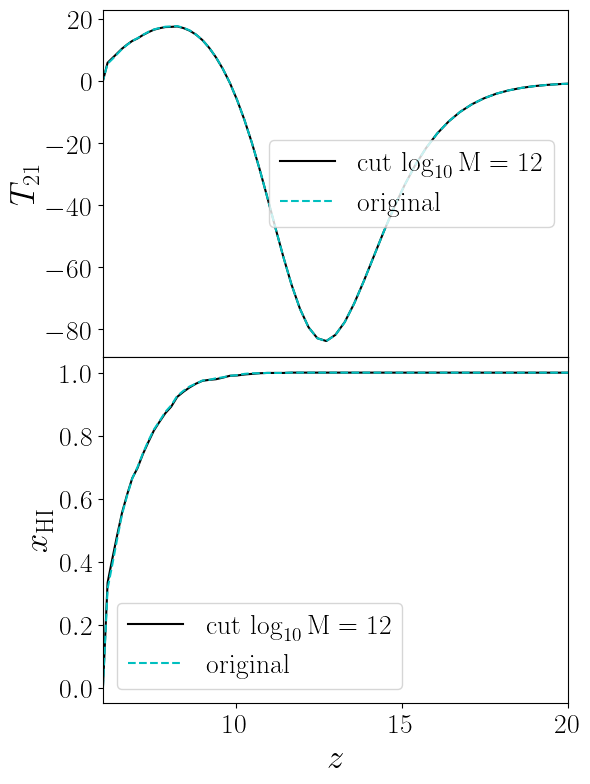

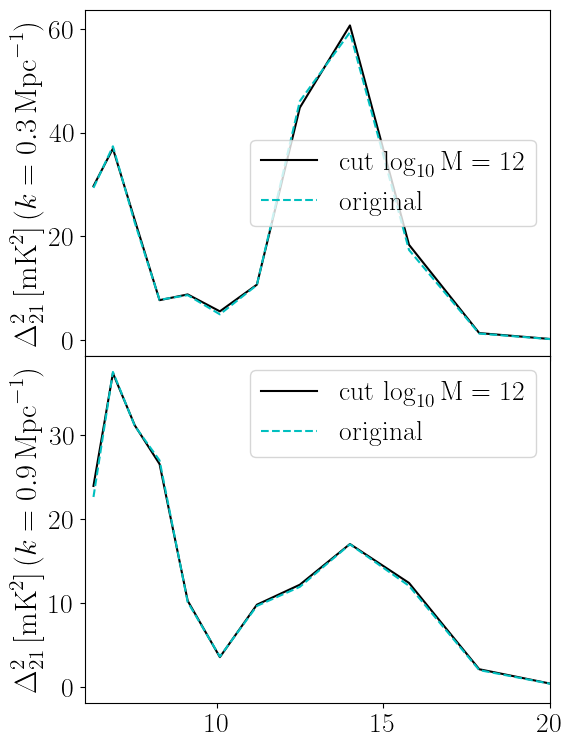

In [50]:
check_Masscut_Gauss(30,10)

In [20]:
import glob 
import os
from scipy.stats import binned_statistic_2d

import matplotlib.colors as colors
from matplotlib.ticker import FuncFormatter

import matplotlib.colors as colors

cmap = plt.get_cmap("RdYlGn_r")

norm = colors.LogNorm(vmin=1., vmax=100.)
norm_corr = colors.LogNorm(vmin=2e0, vmax=1e1)

In [ ]:
def plot_dNion(Lbox, Nbox, fnl):

    dtype = np.dtype([
    ("epsilon",  "f8"), 
    ("Dval",  "f8"),
        ("exponent",        "f8"),
        ("M",        "f8"),
        ("z",        "f8"),
        ("ratio_CGF",        "f8"),
    ])

    files = glob.glob("files/dNion_diag_thread_*_fnl_" + str(int(fnl)) + "_Lbox_" + str(Nbox) + "_Nbox_*.bin")

    total = 0
    for f in files:
        total += os.path.getsize(f) // dtype.itemsize

    data_dNion = np.empty(total, dtype=dtype)

    i = 0
    for f in files:
        d = np.fromfile(f, dtype=dtype)
        data_dNion[i:i+len(d)] = d
        i += len(d)

    Npt = 10000
    N = len(data_dNion)
    idx = np.random.choice(N, size=Npt, replace=False)

    z_dNion = data_dNion["z"][idx]
    M_dNion = data_dNion["M"][idx]
    eps_dNion = data_dNion["epsilon"][idx]
    exponent_dNion = data_dNion["exponent"][idx]
    Dval_dNion = data_dNion["Dval"][idx]
    Ngcorr_dNion = data_dNion["ratio_CGF"][idx]

    # logarithmic mass
    logM = np.log10(M_dNion)
    print(np.max(logM))

    # bin edges
    Nz = 30   # number of z bins
    NM = 30   # number of mass bins

    z_edges = np.linspace(z_dNion.min(), z_dNion.max(), Nz + 1)
    M_edges = np.linspace(logM.min(), logM.max(), NM + 1)

    print("(Lbox,Nbox,fnl)=(" + str(Lbox) + ","+ str(Nbox) + "," + str(fnl) + ",")
    print("percetage of eps > 10: " + str(len(np.where(eps_dNion > 10)[0])/len(eps_dNion)*100))
    print("percetage of D< 0: " + str(len(np.where(Dval_dNion < 0)[0])/len(Dval_dNion)*100))
    print("percetage of exp>700: " + str(len(np.where(exponent_dNion >700)[0])/len(exponent_dNion)*100))


    eps_dNion_map, xedges_dNion, yedges_dNion, _ = binned_statistic_2d(
        z_dNion, logM, eps_dNion,
        statistic="mean",
        bins=[z_edges, M_edges]
    )

    Dval_dNion_map, xedges_Dval_dNion, yedges_Dval_dNion, _ = binned_statistic_2d(
        z_dNion, logM, Dval_dNion,
        statistic="mean",
        bins=[z_edges, M_edges]
    )

    exponent_dNion_map, xedges_exp_dNion, yedges_exp_dNion, _ = binned_statistic_2d(
        z_dNion, logM, exponent_dNion,
        statistic="mean",
        bins=[z_edges, M_edges]
    )

    # Ngcorr_dNion_map, xedges_Ng_dNion, yedges_Ng_dNion, _ = binned_statistic_2d(
    #     z_dNion[np.where(Ngcorr_dNion > 2)], logM[np.where(Ngcorr_dNion > 2)], Ngcorr_dNion[np.where(Ngcorr_dNion > 2)],
    #     statistic="mean",
    #     bins=[z_edges, M_edges]
    # )

    # Ngcorr_dNion_map_low, xedges_Ng_dNion_low, yedges_Ng_dNion_low, _ = binned_statistic_2d(
    #     z_dNion[np.where(Ngcorr_dNion <= 2)], logM[np.where(Ngcorr_dNion <= 2)], Ngcorr_dNion[np.where(Ngcorr_dNion <= 2)],
    #     statistic="mean",
    #     bins=[z_edges, M_edges]
    # )

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14,4))

    for ax in [ax1, ax2, ax3]:
        # ticks
        ax.tick_params(axis='both', which='major',
                    labelsize=14, length=6, width=1.2)

        # labels (x/y axis labels)
        ax.set_xlabel(ax.get_xlabel(), fontsize=16)
        ax.set_ylabel(ax.get_ylabel(), fontsize=16)

        # title
        ax.set_title(ax.get_title(), fontsize=16)

        # legend (if it exists)
        leg = ax.get_legend()
        if leg is not None:
            plt.setp(leg.get_texts(), fontsize=13)
            leg.get_title().set_fontsize(13)

    pc = ax1.pcolormesh(
        xedges_dNion, yedges_dNion,
        eps_dNion_map.T,
        shading="auto",
        cmap=cmap,
        norm=norm
    )

    ax1.set_ylabel(r"$log_{10}(M)$",)
    ax1.set_xlabel(r"$z$",)

    # Create colorbar with custom ticks
    cbar = plt.colorbar(pc, label=r"$ \epsilon $",ax=ax1)

    # Set custom tick locations and labels
    tick_locs = [1, 10, 100]
    tick_labels = [r'$<1$', r'$10$', r'$>100$']
    cbar.set_ticks(tick_locs,)
    cbar.set_ticklabels(tick_labels)

    # Move the label closer
    cbar.ax.yaxis.set_label_coords(3, 0.5)

    # ax1.set_ylim(7,20)
    ax1.set_title("dNion_General validity map",)
    # ax1.set_xlim(6,35)

    pc = ax2.pcolormesh(
        xedges_Dval_dNion, yedges_Dval_dNion,
        Dval_dNion_map.T,
        shading="auto",
        cmap='RdYlGn',vmin = -10,vmax=0
        #norm=norm
    )

    ax2.set_ylabel(r"$log_{10}(M)$",)
    ax2.set_xlabel(r"$z$",)

    # Create colorbar with custom ticks
    cbar = plt.colorbar(pc, label=r"$ D $",ax=ax2)

    # Set custom tick locations and labels

    # Move the label closer
    cbar.ax.yaxis.set_label_coords(3, 0.5)

    # ax3.set_ylim(7,20)
    ax2.set_title("dNion_General Dval",)
    # ax3.set_xlim(6,35)

    pc = ax3.pcolormesh(
        xedges_exp_dNion, yedges_exp_dNion,
        exponent_dNion_map.T,
        shading="auto",
        cmap=cmap,vmin = 700, 
        #norm=norm
    )

    ax3.set_ylabel(r"$log_{10}(M)$",)
    ax3.set_xlabel(r"$z$",)

    # Create colorbar with custom ticks
    cbar = plt.colorbar(pc, label=r"$ exponent $",ax=ax3)

    # Set custom tick locations and labels

    # Move the label closer
    cbar.ax.yaxis.set_label_coords(3, 0.5)

    # ax4.set_ylim(7,20)
    ax3.set_title("dNion_General Dval",)
    # ax4.set_xlim(6,35)

    plt.savefig('figures/dNion_Lbox_' + str(Lbox) + '_Nbox_' + str(Nbox) + '_fnl_' + str(fnl) + '.png')
    
    return 

11.998711290653933
(Lbox,Nbox,fnl)=(30,10,10.0,
percetage of eps > 10: 1.92
percetage of D< 0: 0.0
percetage of exp>700: 0.0


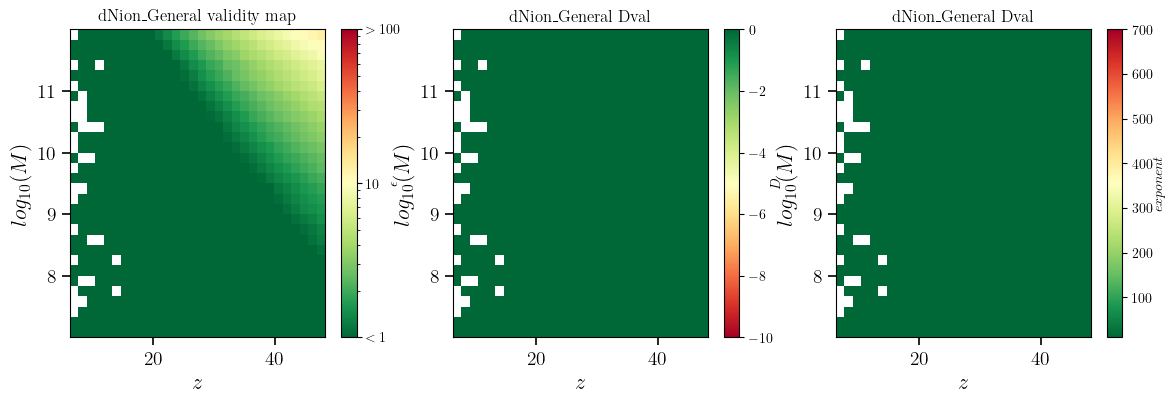

In [54]:
plot_dNion(30, 10, 10.)


11.998711290653933
(Lbox,Nbox,fnl)=(30,10,-10.0,
percetage of eps > 10: 1.8399999999999999
percetage of D< 0: 0.0
percetage of exp>700: 0.0


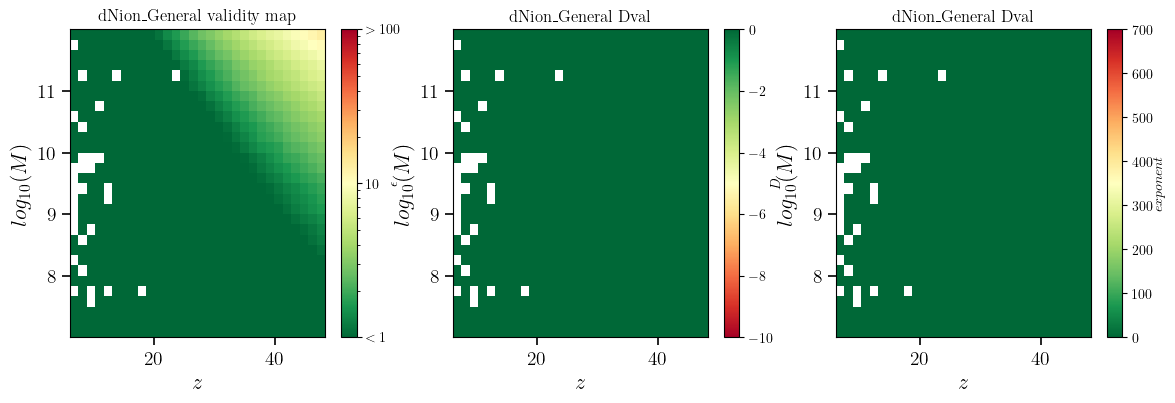

In [51]:
plot_dNion(30, 10, -10.)

11.998711290653933
(Lbox,Nbox,fnl)=(30,10,50.0,
percetage of eps > 10: 27.060000000000002
percetage of D< 0: 0.0
percetage of exp>700: 0.0


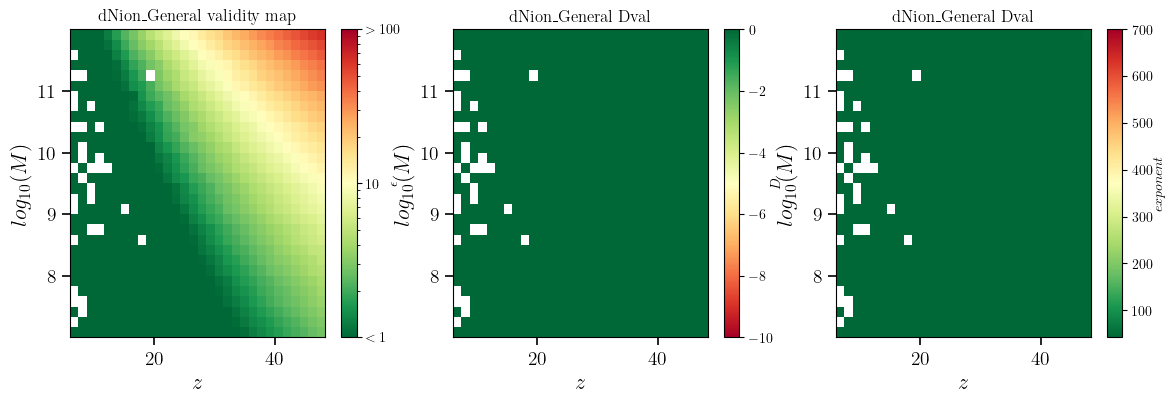

In [55]:
plot_dNion(30, 10, 50.)


11.999355645326967
(Lbox,Nbox,fnl)=(30,10,-50.0,
percetage of eps > 10: 28.24
percetage of D< 0: 0.06999999999999999
percetage of exp>700: 0.0


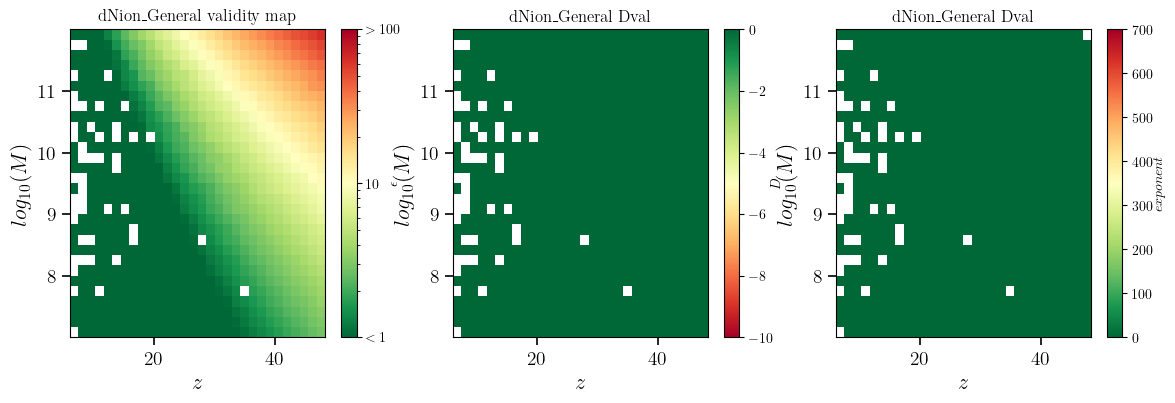

In [52]:
plot_dNion(30, 10, -50.)

11.999355645326967
(Lbox,Nbox,fnl)=(30,10,100.0,
percetage of eps > 10: 49.309999999999995
percetage of D< 0: 0.0
percetage of exp>700: 0.0


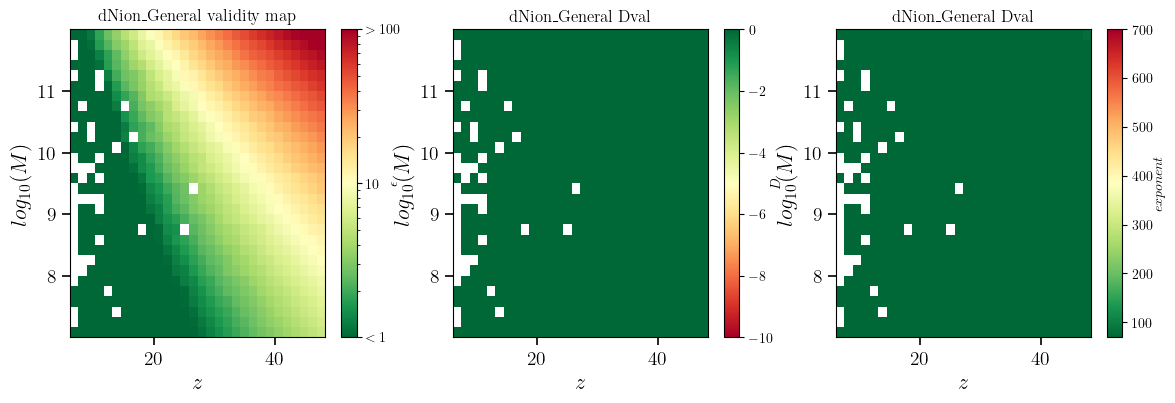

In [60]:
plot_dNion(30, 10, 100.)


In [61]:
plot_dNion(30, 10, -100.)

/tmp/ipykernel_1754061/1446910272.py:38: RuntimeWarning: invalid value encountered in log10
  logM = np.log10(M_dNion)


nan
(Lbox,Nbox,fnl)=(30,10,-100.0,
percetage of eps > 10: 71.32
percetage of D< 0: 41.339999999999996
percetage of exp>700: 0.0


ValueError: cannot convert float NaN to integer

11.999355645326967
(Lbox,Nbox,fnl)=(30,10,300.0,
percetage of eps > 10: 73.35000000000001
percetage of D< 0: 0.0
percetage of exp>700: 0.0


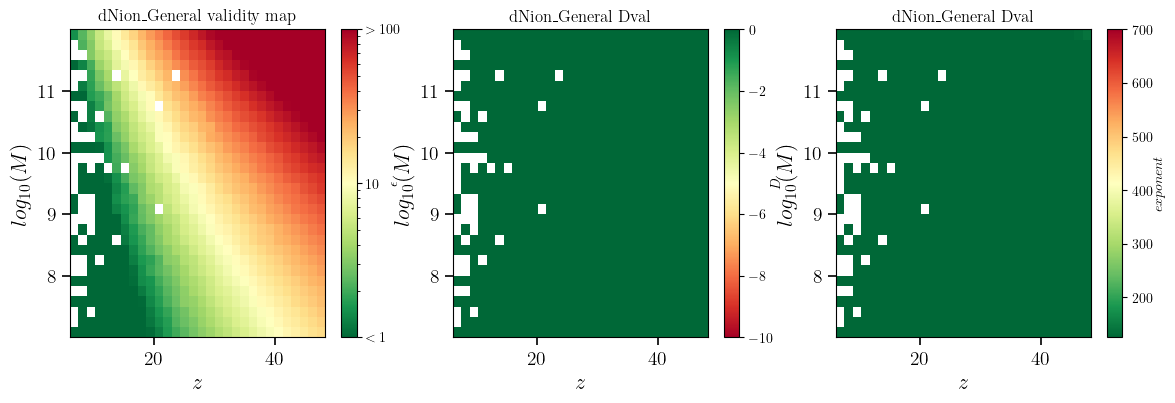

In [56]:
plot_dNion(30, 10, 300.)


11.999677822663484
(Lbox,Nbox,fnl)=(30,10,-300.0,
percetage of eps > 10: 27.76
percetage of D< 0: 67.86
percetage of exp>700: 0.0


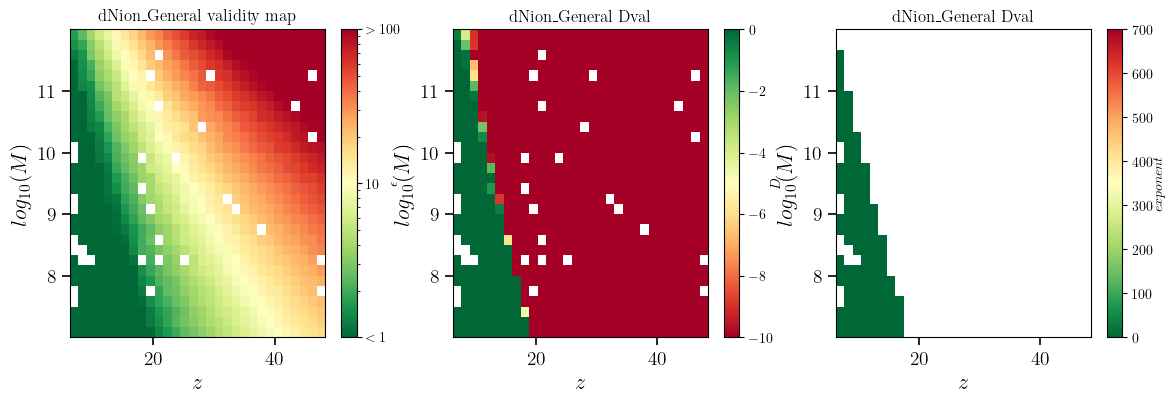

In [53]:
plot_dNion(30, 10, -300.)

In [7]:
colors = [
    # 
    # # # "#bfe6ff",  # very light blue

    # "#ffd0c7",  # pale salmon
    "#ff6b4a",  # vivid orange-red
    "#c1272d",  # strong red
    "#5c0000",  # dark maroon
]

In [8]:
def plot_globals(Lbox, Nbox, fnl):

    if Lbox == 50 and Nbox == 50:
        cut = fnl0_50 
    else:
        cut = fnl0

        
    fig, (ax, ax1) = plt.subplots(2,1, figsize=(6,9),sharex=True,    gridspec_kw={'hspace': 0})

    flag = ['brightness_temp', 'xH_box']

    for i in range(len(flag)):

        for fnl_val in fnl:

            if Lbox == 50 and Nbox == 50:
                if fnl_val == 10.:
                    fnl_spectrum = fnl10_50
                elif fnl_val == -10.:
                    fnl_spectrum = fnlm10_50
                elif fnl_val == 300.:
                    fnl_spectrum = fnl300_50
                elif fnl_val == -300.:
                    fnl_spectrum = fnlm300_50
            else:
                if fnl_val == 10.:
                    fnl_spectrum = fnl10
                elif fnl_val == -10.:
                    fnl_spectrum = fnlm10
                elif fnl_val == 50.:
                    fnl_spectrum = fnl50
                elif fnl_val == -50.:
                    fnl_spectrum = fnlm50
                elif fnl_val == 200.:
                    fnl_spectrum = fnl200
                elif fnl_val == -200.:
                    fnl_spectrum = fnlm200
                elif fnl_val == 100.:
                    fnl_spectrum = fnl100
                elif fnl_val == -100.:
                    fnl_spectrum = fnlm100
                elif fnl_val == 300.:
                    fnl_spectrum = fnl300
                elif fnl_val == -300.:
                    fnl_spectrum = fnlm300

            p21c.plotting.plot_global_history(fnl_spectrum,
                                                # you can specify the following properties for your plot; if None (or omitted) defaults are used
                                                kind = flag[i], # which quantity to plot, choose between the one listed in global_quantities
                                                x_kind='redshift', # this argument specifies plotted on the x-axis; can be set to 'redshift', 'frequency', or 'distance'
                                                xlabel = '' if i == 0 else r'$z$',
                                                ylabel = r'$T_{21}$' if i == 0 else r'$x_{\rm HI}$',
                                                xlog = False,
                                                ylog = False,
                                                # Note that this function accepts all the arguments of 'matplotlib.pyplot.plot'!
                                                ls='-',ax=ax if i == 0 else ax1,color=colors[fnl.index(fnl_val)],
                                               label=r'$f_{\rm NL}=%g$'%fnl_val if i > 0 else ''
                                                ) 

        p21c.plotting.plot_global_history(cut,
                                            # you can specify the following properties for your plot; if None (or omitted) defaults are used
                                            kind = flag[i], # which quantity to plot, choose between the one listed in global_quantities
                                            x_kind='redshift', # this argument specifies plotted on the x-axis; can be set to 'redshift', 'frequency', or 'distance'
                                            xlabel = '' if i == 0 else r'$z$',
                                            ylabel = r'$T_{21}$' if i == 0 else r'$x_{\rm HI}$',
                                            xlog = False,
                                            ylog = False,
                                            # Note that this function accepts all the arguments of 'matplotlib.pyplot.plot'!
                                            color = 'k',
                                            ls='-',ax=ax if i == 0 else ax1,
                                            label=r'$f_{\rm NL}=0$' if i > 0 else ''

                                            ) 
    ax.set_xlim(6.,20.)
    ax1.set_xlim(6.,20.)

    plt.savefig('figures/globals_' + str(Lbox) + str(Nbox) + '.png')
    plt.show()
    return 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


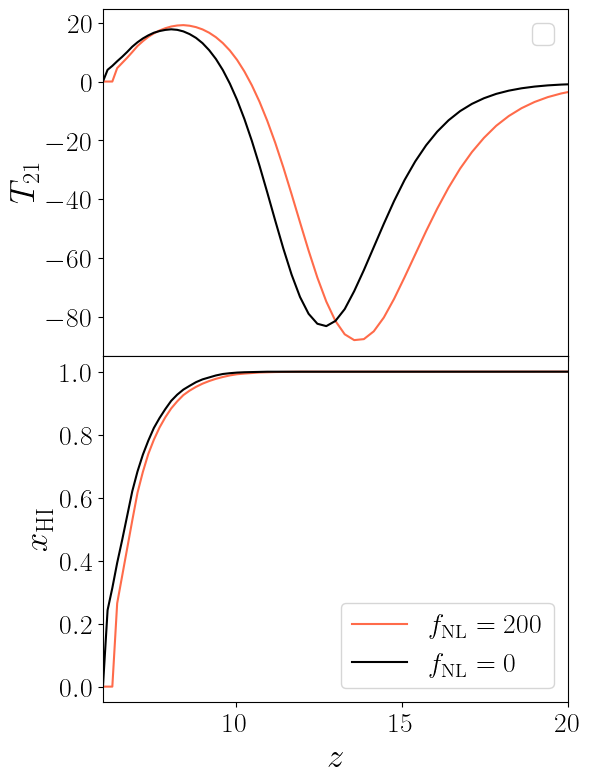

In [9]:
plot_globals(30,10, [200.])
# plot_globals(30,10, [-300.,-100.,-50.,-10.,10.,50.,100.,300.])

In [10]:
def plot_pk(Lbox, Nbox, fnl):

    cut = fnl0

    freq_bands_boundaries = np.arange(50.,225.+8.,8.); freq_bands_boundaries[-1] = 225.
    # ps0 = p21c.power_spectrum.lightcone_power_spectrum(cut,nchunks = 15) 
    ps0 = p21c.power_spectrum.lightcone_power_spectrum(cut,
                                                  freq_bands_boundaries = freq_bands_boundaries) ; 
    psNL = []  
    for fnl_val in fnl:

        if fnl_val == 10.:
            fnl_spectrum = fnl10
        elif fnl_val == -10.:
            fnl_spectrum = fnlm10
        elif fnl_val == 50.:
            fnl_spectrum = fnl50
        elif fnl_val == -50.:
            fnl_spectrum = fnlm50
        elif fnl_val == -100.:
            fnl_spectrum = fnlm100
        elif fnl_val == 200.:
            fnl_spectrum = fnl200
        elif fnl_val == -200.:
            fnl_spectrum = fnlm200
        elif fnl_val == 100.:
            fnl_spectrum = fnl100
        elif fnl_val == 300.:
            fnl_spectrum = fnl300
        elif fnl_val == -300.:
            fnl_spectrum = fnlm300

        psNL.append(p21c.power_spectrum.lightcone_power_spectrum(fnl_spectrum,
                                                  freq_bands_boundaries = freq_bands_boundaries)) ; 


    fig, (ax, ax1) = plt.subplots(2,1, figsize=(6,9),sharex=True,    gridspec_kw={'hspace': 0})

    ks = [0.1,0.3]

    for i in range(len(ks)):

        for fnl_val in range(len(fnl)):

            p21c.plotting.plot_1d_power_spectrum(psNL[fnl_val],
                                                    k=ks[i], # scale in units 1/Mpc
                                                    # you can specify the following properties for your plot; if None (or omitted) defaults are used
                                                    smooth=True, # the curve can be smoothed by interpolating in intermediate points
                                                    xlabel = '',
                                                    ylabel = None,
                                                    xlog = False, # linear scale on the x-axis by default
                                                    ylog = False, # log scale on the y-axis by default
                                                    # Note that this function accepts all the arguments of 'matplotlib.pyplot.plot'!
                                                ls='-',ax=ax if i == 0 else ax1,color=colors[fnl.index(fnl[fnl_val])]
                                            #    label=r'$f_{nl}=%g$'%fnl[fnl_val]
                                                ) 

        p21c.plotting.plot_1d_power_spectrum(ps0,
                                                k=ks[i], # scale in units 1/Mpc
                                                # you can specify the following properties for your plot; if None (or omitted) defaults are used
                                                smooth=True, # the curve can be smoothed by interpolating in intermediate points
                                                xlabel = '',
                                                ylabel = None,
                                                xlog = False, # linear scale on the x-axis by default
                                                ylog = False, # log scale on the y-axis by default
                                                # Note that this function accepts all the arguments of 'matplotlib.pyplot.plot'!
                                                color = 'k',
                                            ls='-',ax=ax if i == 0 else ax1,
                                            # label=r'$L=%g$'%Lbox + r'$,N=%g,$'%Nbox + r'$\rm cut\, \log_{10}M=%g$'%cut_mass

                                            ) 

    ax.set_xlim(6.,20.)
    ax1.set_xlim(6.,20.)

    plt.savefig('figures/pk_' + str(Lbox) + str(Nbox) + '.png')
    plt.show()
    return 

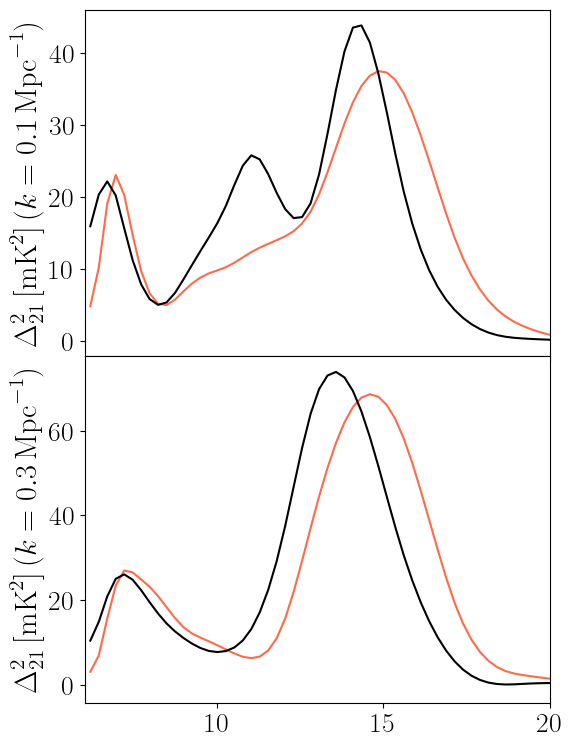

In [11]:
plot_pk(100, 25, [200.])
# plot_pk(30, 10, [-300., -100.,-50.,-10.,10.,50.,100.,300.])

In [33]:
def plot_dNdm(Lbox, Nbox, fnl):

    dtype = np.dtype([
        ("epsilon",  "f8"),
        ("M1",        "f8"),
        ("z",        "f8"),
        ("Ngcorr",   "f8"),
    ])
    files = glob.glob("files/cgf_diag_thread_*_fnl_" + str(int(fnl)) + "_Lbox_" + str(Nbox) + "_Nbox_*.bin")

    # compute total number of records
    total = 0
    for f in files:
        total += os.path.getsize(f) // dtype.itemsize

    data = np.empty(total, dtype=dtype)

    i = 0
    for f in files:
        d = np.fromfile(f, dtype=dtype)
        data[i:i+len(d)] = d
        i += len(d)



    Npt = 10000
    N = len(data)
    idx = np.random.choice(N, size=Npt, replace=False)

    z = data["z"][idx]
    M = data["M1"][idx]
    eps = data["epsilon"][idx]
    Ngcorr = data["Ngcorr"][idx]

    # logarithmic mass
    logM = np.log10(M)
    print(np.max(logM))

    # bin edges
    Nz = 30   # number of z bins
    NM = 30   # number of mass bins

    z_edges = np.linspace(z.min(), z.max(), Nz + 1)

    M_edges = np.linspace(logM.min(), logM.max(), NM + 1)

    print("(Lbox,Nbox,fnl)=(" + str(Lbox) + ","+ str(Nbox) + "," + str(fnl) + ",")


    val_low = 1

    eps_map, xedges, yedges, _ = binned_statistic_2d(
        z, logM, eps,
        statistic="mean",
        bins=[z_edges, M_edges]
    )

    Ngcorr_map, xedges_Ng, yedges_Ng, _ = binned_statistic_2d(
        z, logM, Ngcorr,
        statistic="mean",
        bins=[z_edges, M_edges]
    )

    fig, (ax1) = plt.subplots(1, 1, figsize=(3.5,3.5))

    for ax in [ax1]:
        # ticks
        ax.tick_params(axis='both', which='major',
                    labelsize=14, length=6, width=1.2)

        # labels (x/y axis labels)
        ax.set_xlabel(ax.get_xlabel(), fontsize=16)
        ax.set_ylabel(ax.get_ylabel(), fontsize=16)

        # title
        ax.set_title(ax.get_title(), fontsize=16)

        # legend (if it exists)
        leg = ax.get_legend()
        if leg is not None:
            plt.setp(leg.get_texts(), fontsize=13)
            leg.get_title().set_fontsize(13)

    pc = ax1.pcolormesh(
        xedges, yedges,
        eps_map.T,
        shading="auto",
        cmap=cmap,zorder=1,
        norm=norm
    )


    ax1.set_ylabel(r"$log_{10}(M)$",)
    ax1.set_xlabel(r"$z$",)

    # Create colorbar with custom ticks
    cbar = plt.colorbar(pc, label=r"$ \epsilon $",ax=ax1)

    # Set custom tick locations and labels
    tick_locs = [1, 10, 100]
    tick_labels = [r'$<1$', r'$10$', r'$>100$']
    cbar.set_ticks(tick_locs,)
    cbar.set_ticklabels(tick_labels)

    # Move the label closer
    cbar.ax.yaxis.set_label_coords(3, 0.5)

    ax1.set_ylim(7,12)
    ax1.set_title("dNdm_conditional validity map",)
    ax1.set_xlim(6,35)

    # pc = ax2.pcolormesh(
    #     xedges_Ng_low, yedges_Ng_low,
    #     Ngcorr_map_low.T,
    #     shading="auto",alpha=0.3,
    #     cmap=cmap,vmin=1, vmax=100,zorder=0,
    #     # norm=norm_corr
    # )

    # pc = ax2.pcolormesh(
    #     xedges_Ng, yedges_Ng,
    #     Ngcorr_map.T,
    #     shading="auto",
    #     cmap=cmap,vmin=1, vmax=100,zorder=1,
    #     # norm=norm_corr
    # )

    # ax2.set_ylabel(r"$log_{10}(M)$",)
    # ax2.set_xlabel(r"$z$",)

    # # Create colorbar with custom ticks
    # cbar = plt.colorbar(pc, label=r"$ \rm NG / Gauss $",ax=ax2)

    # # Set custom tick locations and labels
    # # tick_locs = [1, 10, 100]
    # # tick_labels = [r'$<1$', r'$10$', r'$>100$']
    # # cbar.set_ticks(tick_locs,)
    # # cbar.set_ticklabels(tick_labels)

    # # Move the label closer
    # cbar.ax.yaxis.set_label_coords(3, 0.5)

    # ax2.set_title("dNdm_conditional correction map",)

    # ax2.set_ylim(7,12)
    # ax2.set_xlim(6,35)

    plt.savefig('figures/dNdmcond_Lbox_' + str(Lbox) + '_Nbox_' + str(Nbox) + '_fnl_' + str(fnl) + '.png')
    
    return 

11.999999698150742
(Lbox,Nbox,fnl)=(30,10,10.0,


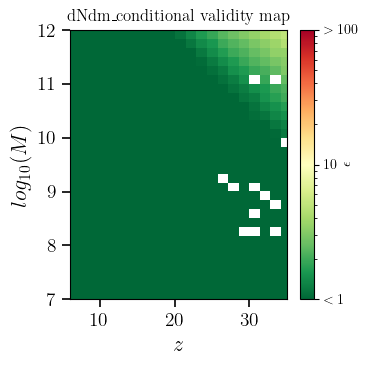

In [34]:
plot_dNdm(30, 10, 10.)

11.999999668736088
(Lbox,Nbox,fnl)=(30,10,-10.0,


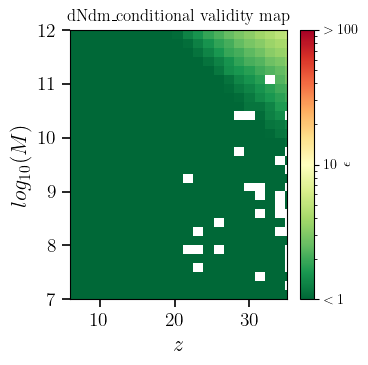

In [35]:
plot_dNdm(30, 10, -10.)

11.999999690097706
(Lbox,Nbox,fnl)=(30,10,300.0,


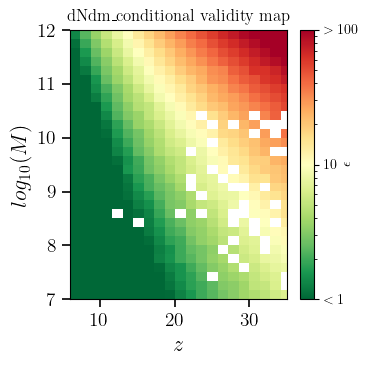

In [36]:
plot_dNdm(30, 10, 300.)


11.999999337472177
(Lbox,Nbox,fnl)=(30,10,-300.0,


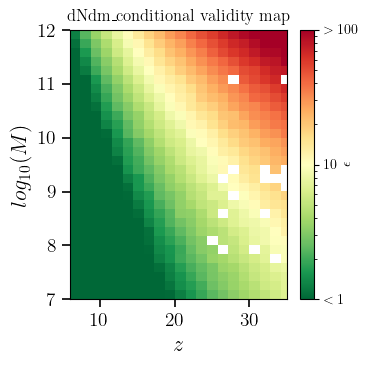

In [37]:
plot_dNdm(30, 10, -300.)

11.999999691986678
(Lbox,Nbox,fnl)=(30,10,50.0,


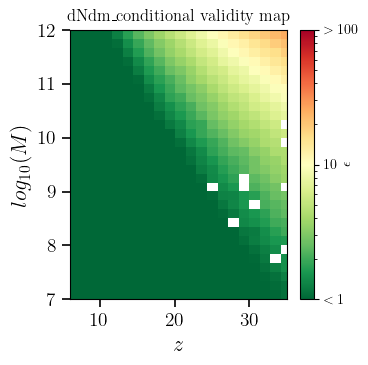

In [38]:
plot_dNdm(30, 10, 50.)

11.999999337472177
(Lbox,Nbox,fnl)=(30,10,-50.0,


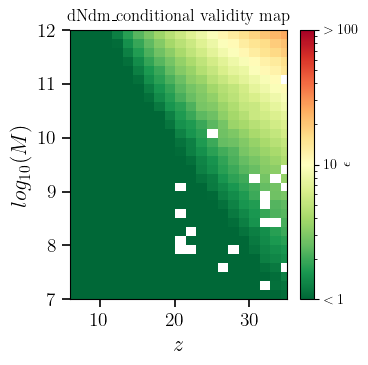

In [39]:
plot_dNdm(30, 10, -50.)

In [9]:
def plot_boxes(Lbox, Nbox, fnl):

    if fnl == 0.:
        lc = fnl0
    elif fnl == 10.:
        lc = fnl10
    elif fnl == -10.:
        lc = fnlm10
    elif fnl == -50.:
        lc = fnlm50
    elif fnl == 50.:
        lc = fnl50
    elif fnl == 100.:
        lc = fnl100
    elif fnl == -100.:
        lc = fnlm100
    elif fnl == 300.:
        lc = fnl300
    elif fnl == -300.:
        lc = fnlm300

    # plot the coeval boxes next to each other
    fig, ax = plt.subplots(1, 3, figsize=(30, 8))

    z  = [7.,11.,15.]
    vmin = [0.,-60.,-100.]
    vmax = [30.,0.,-20.,]
    for zz in range(len(z)):

        p21c.plotting.coeval_sliceplot(lc,
                                        redshift=z[zz],
                                        ax=ax[zz],vmin=vmin[zz],vmax=vmax[zz],)

        ax[zz].set_ylabel('')

        ax[zz].set_title(r'$z=%g$'%z[zz] + r'$,\,f_{NL}=%g$'%fnl)
    plt.savefig('figures/boxes_fnl_' + str(fnl) + '_Lbox_' + str(Lbox) + '_Nbox_' + str(Nbox) + '_fnl_' + str(fnl) + '.png')

    return 


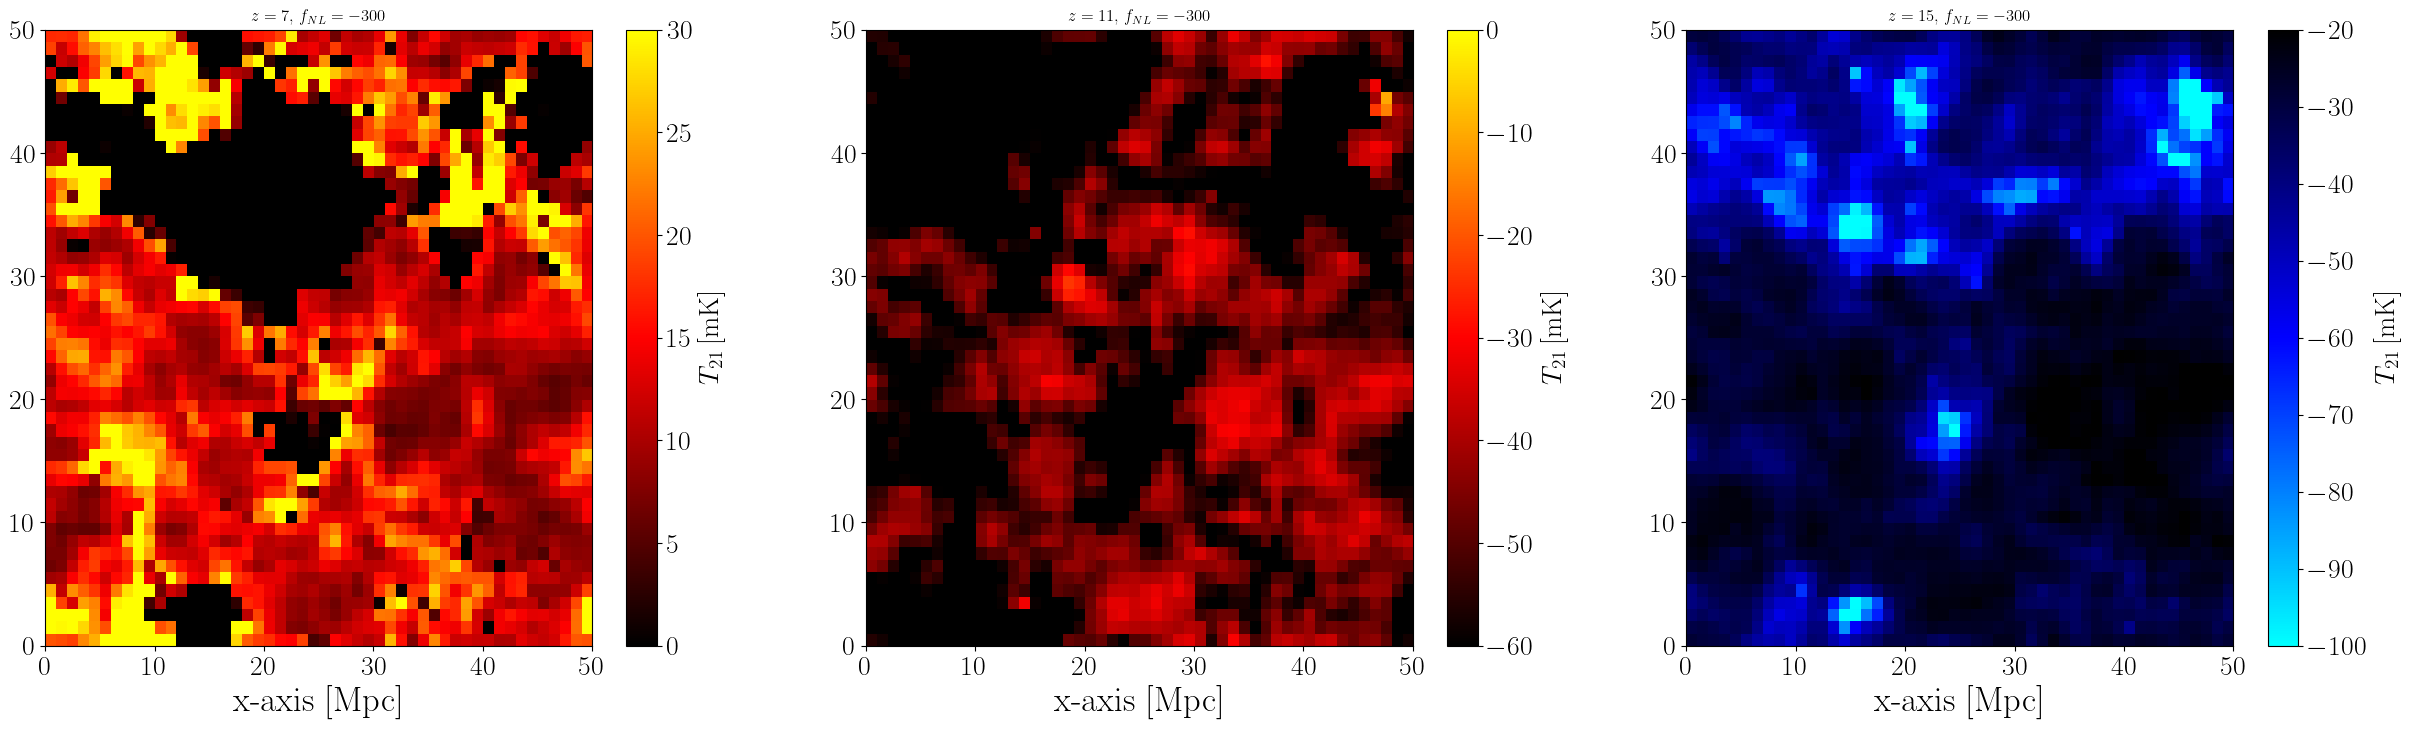

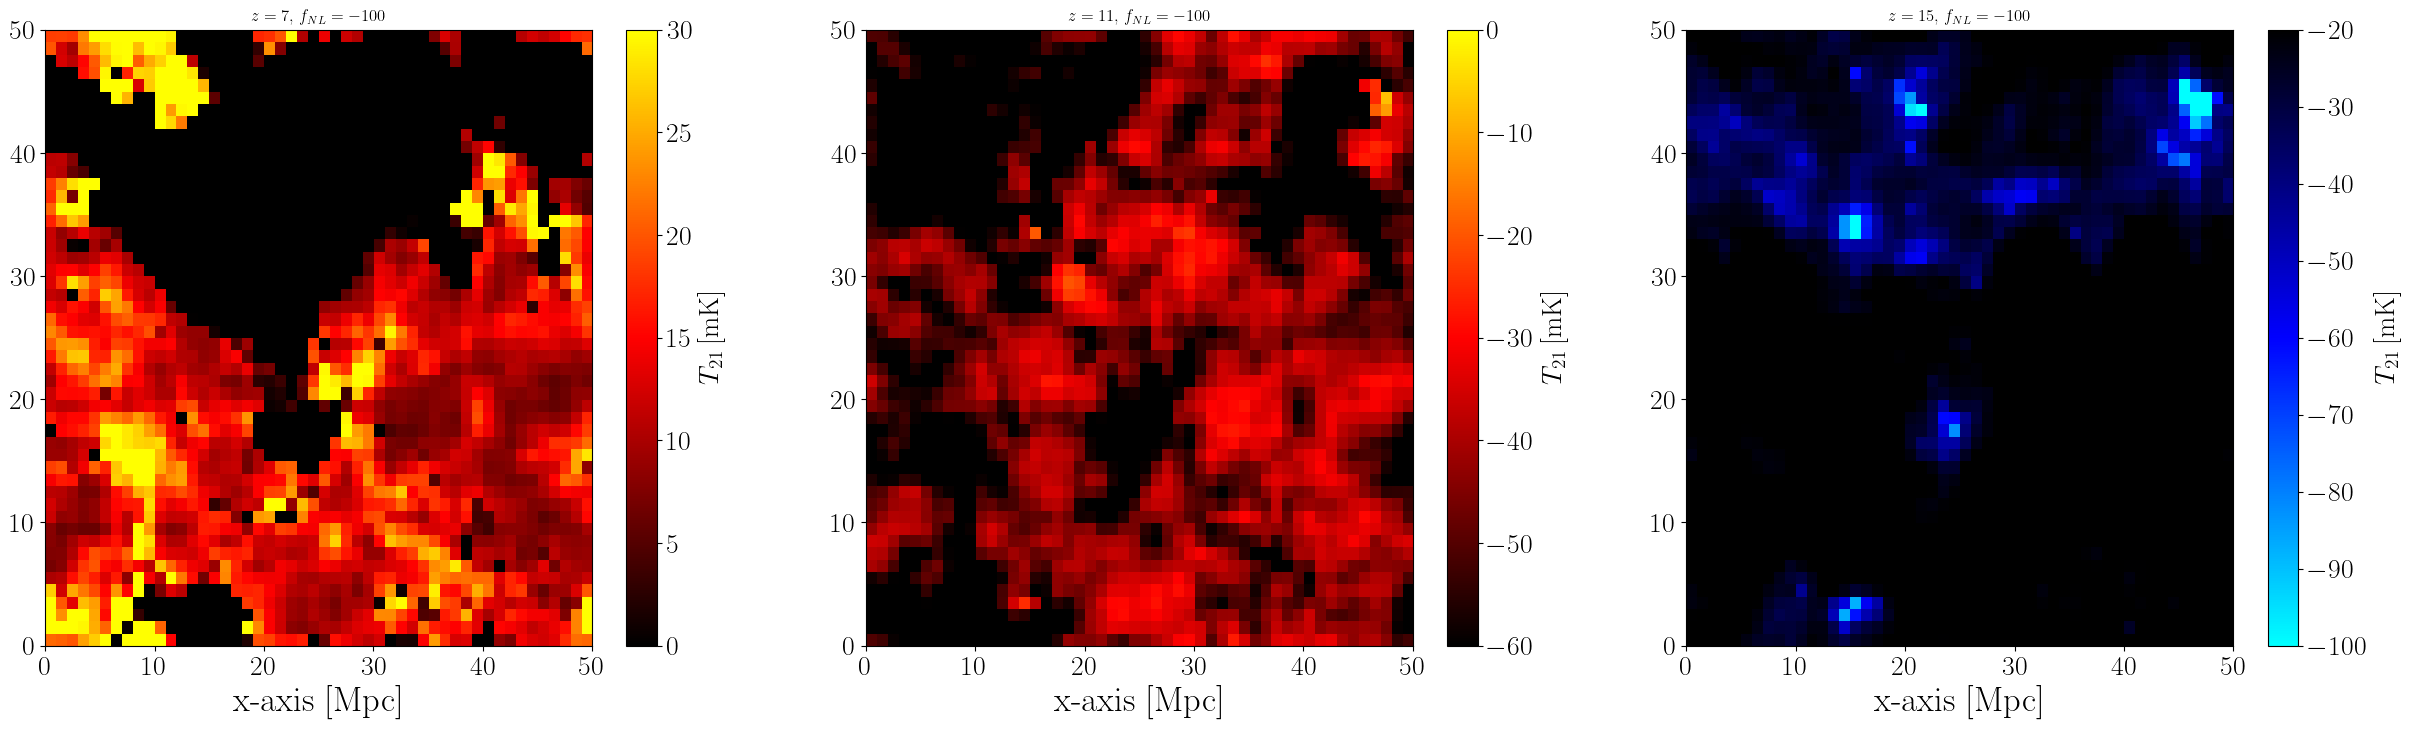

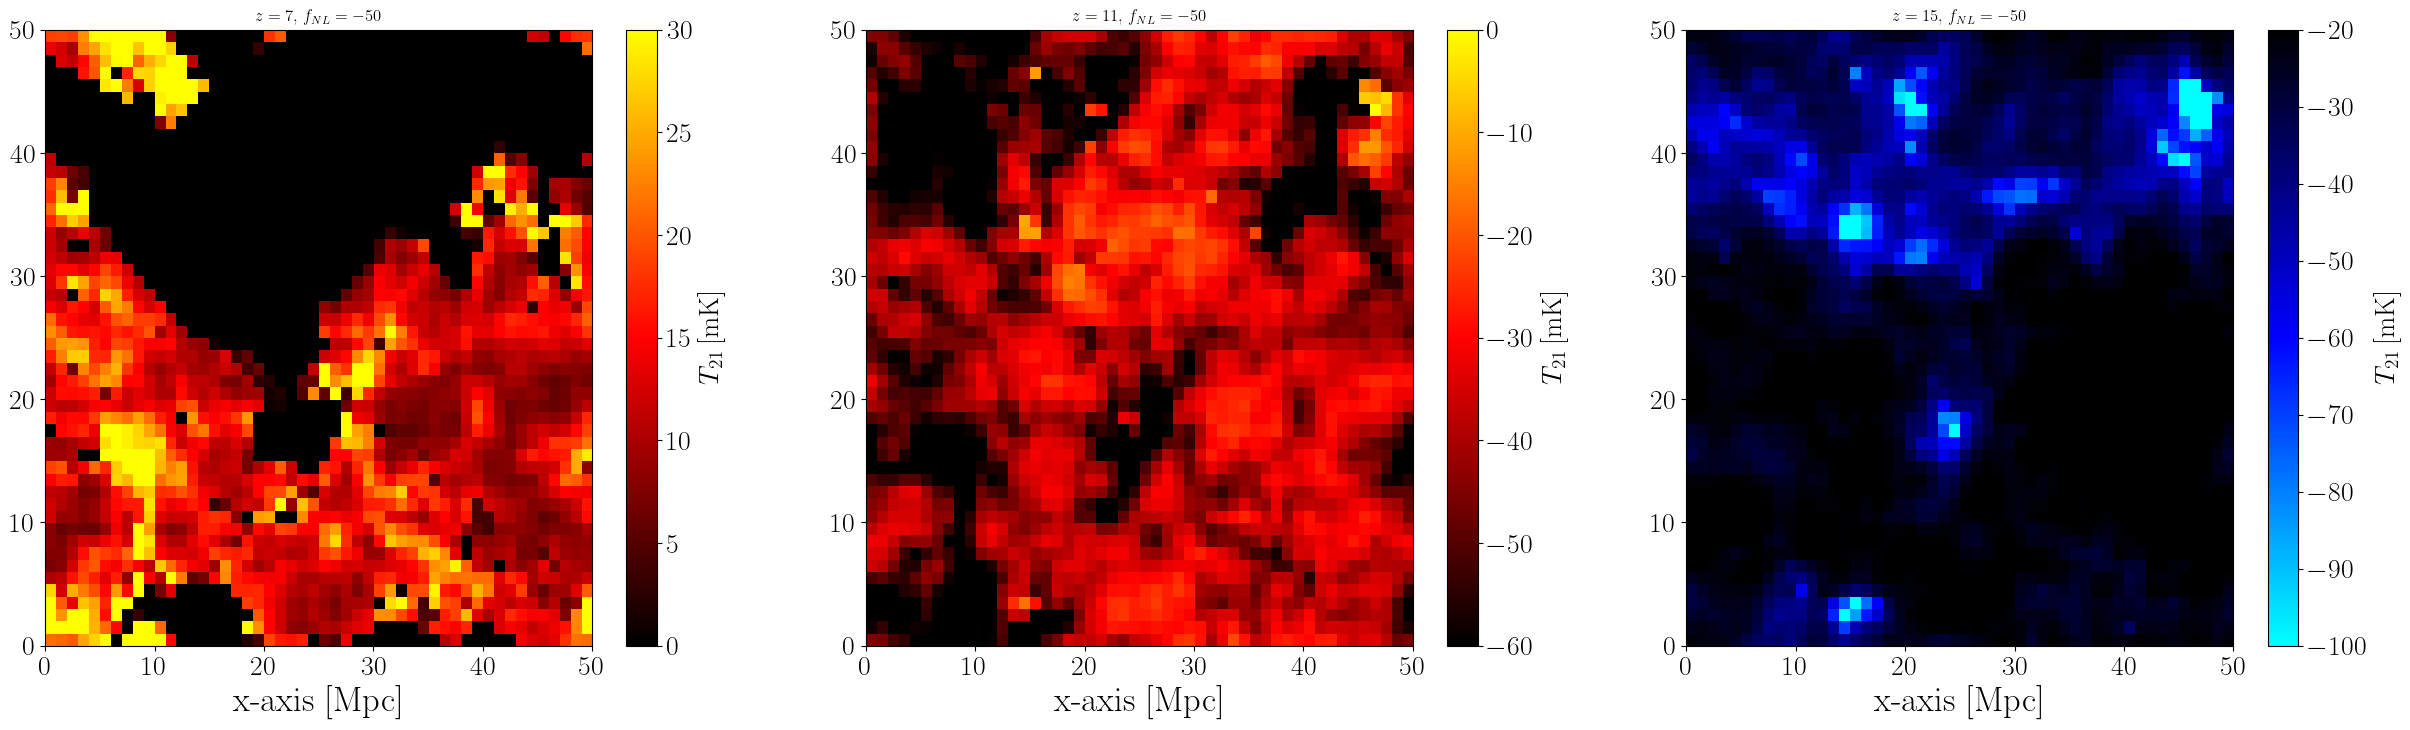

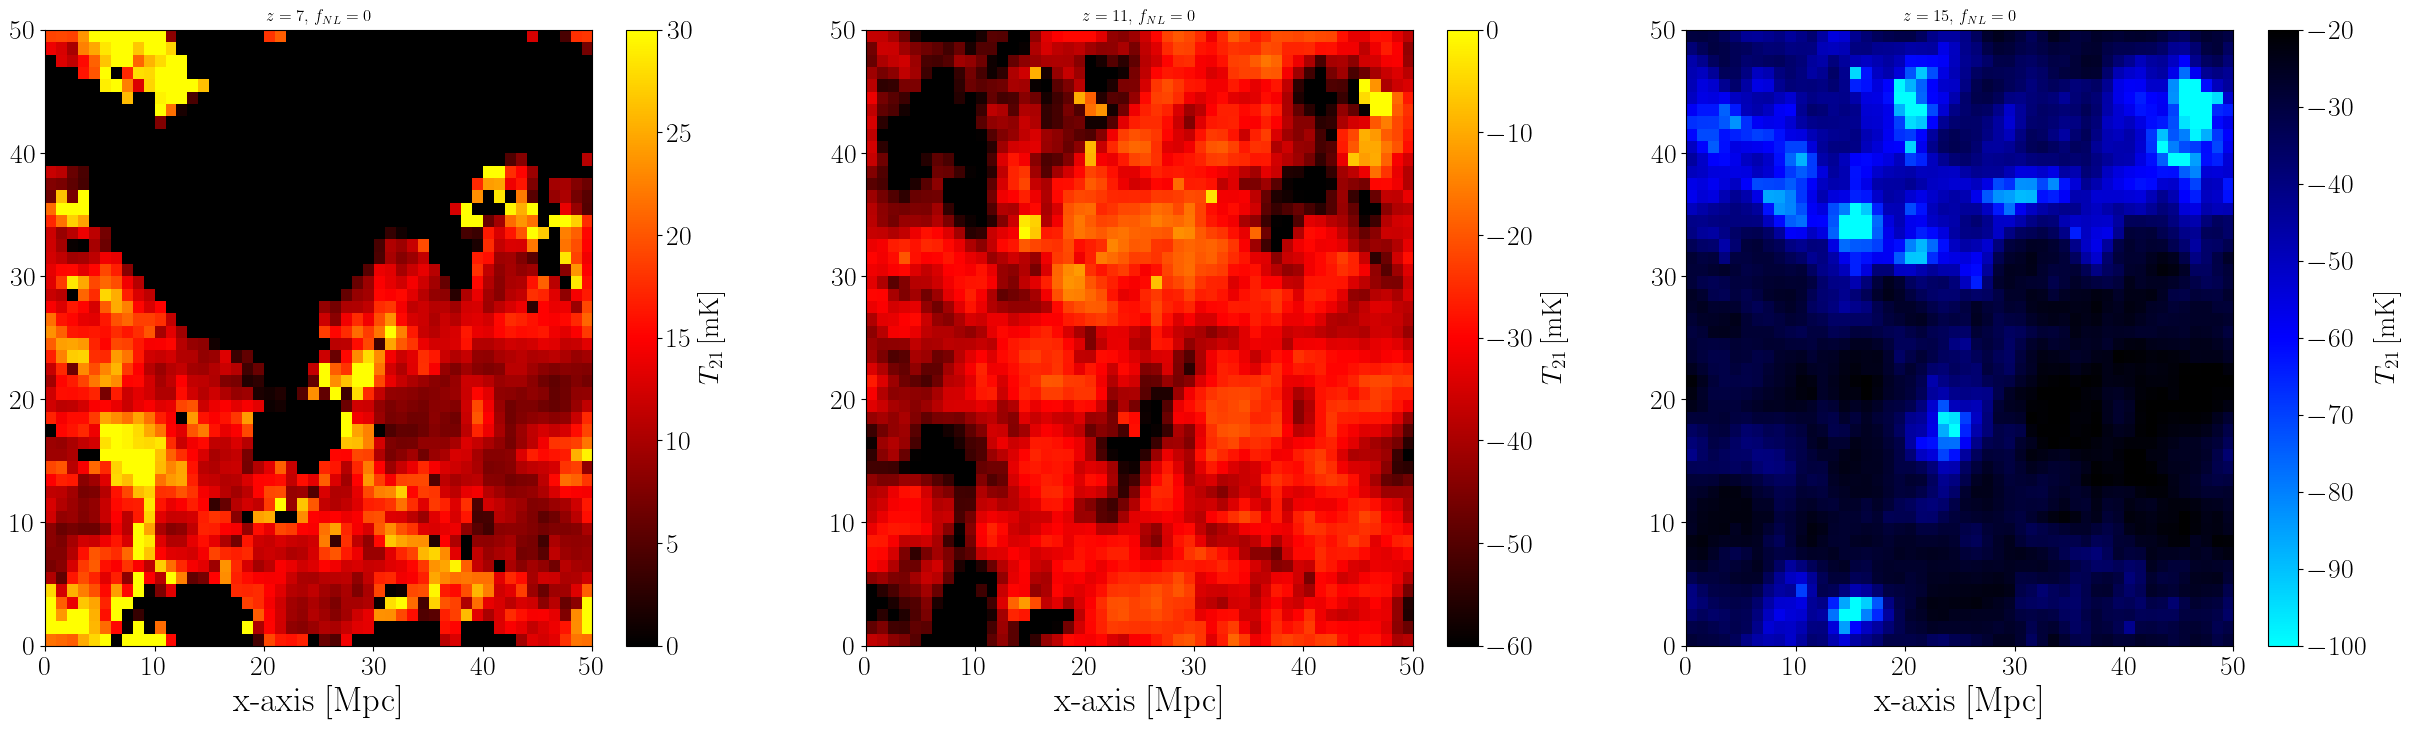

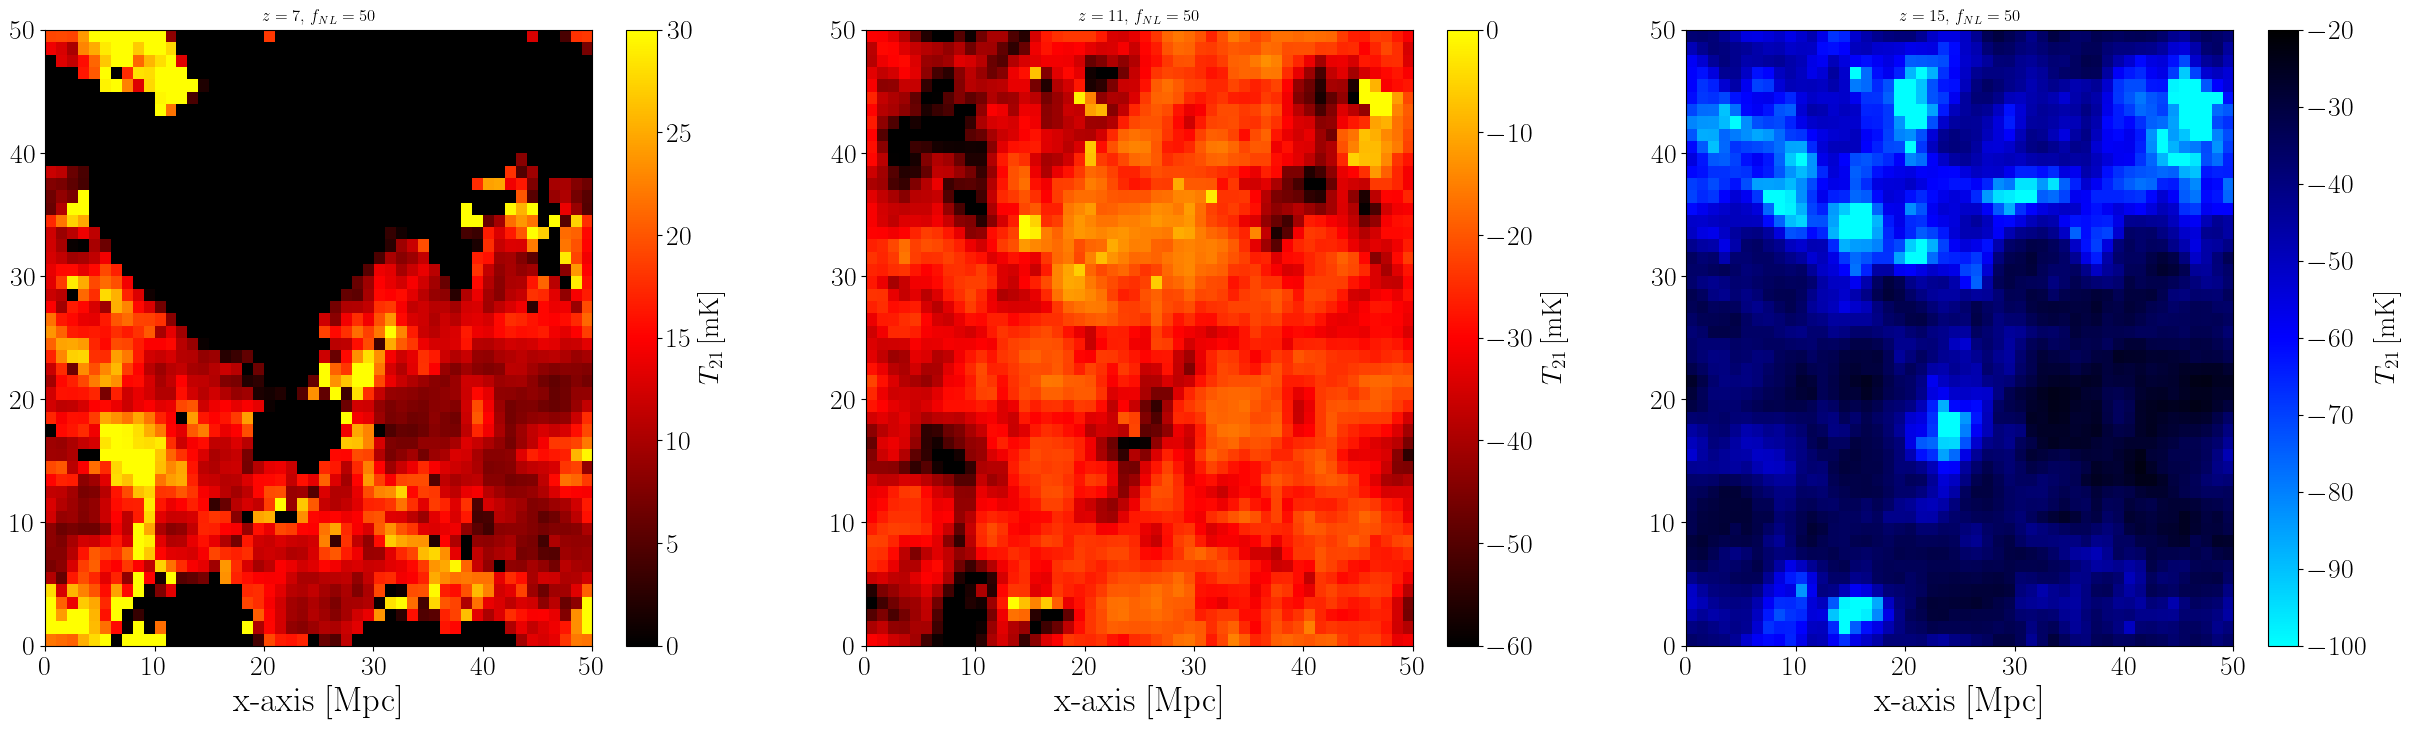

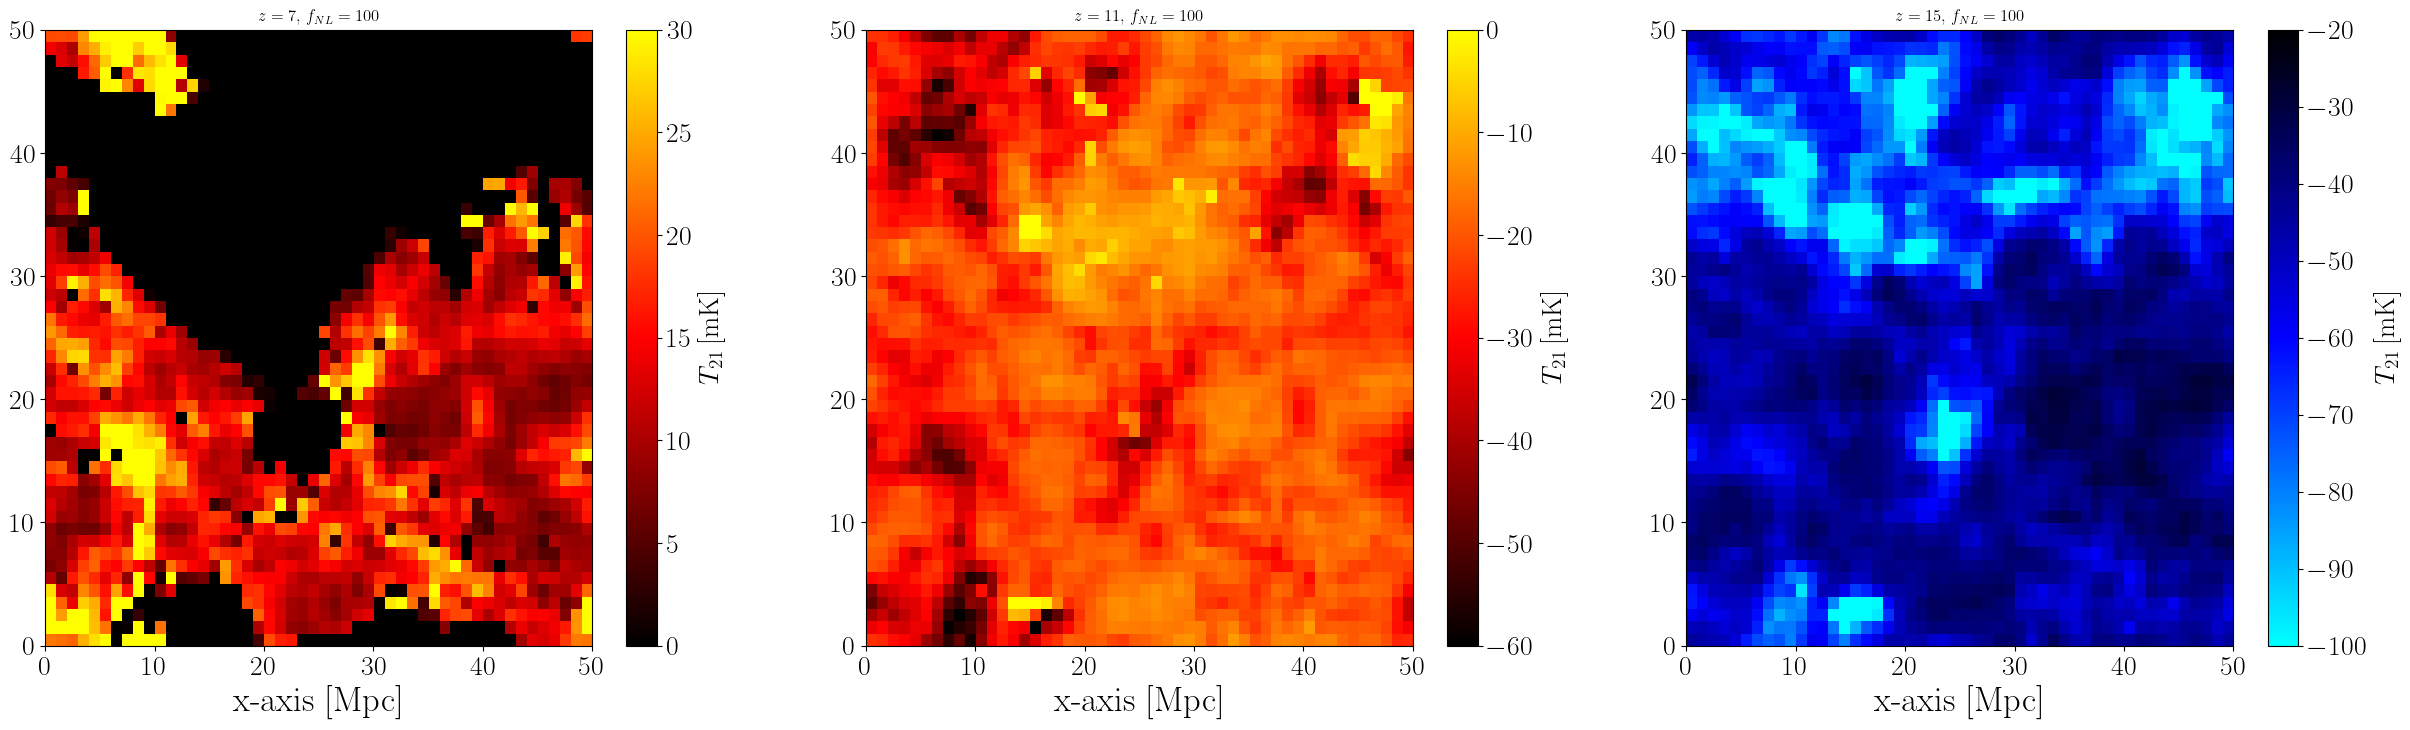

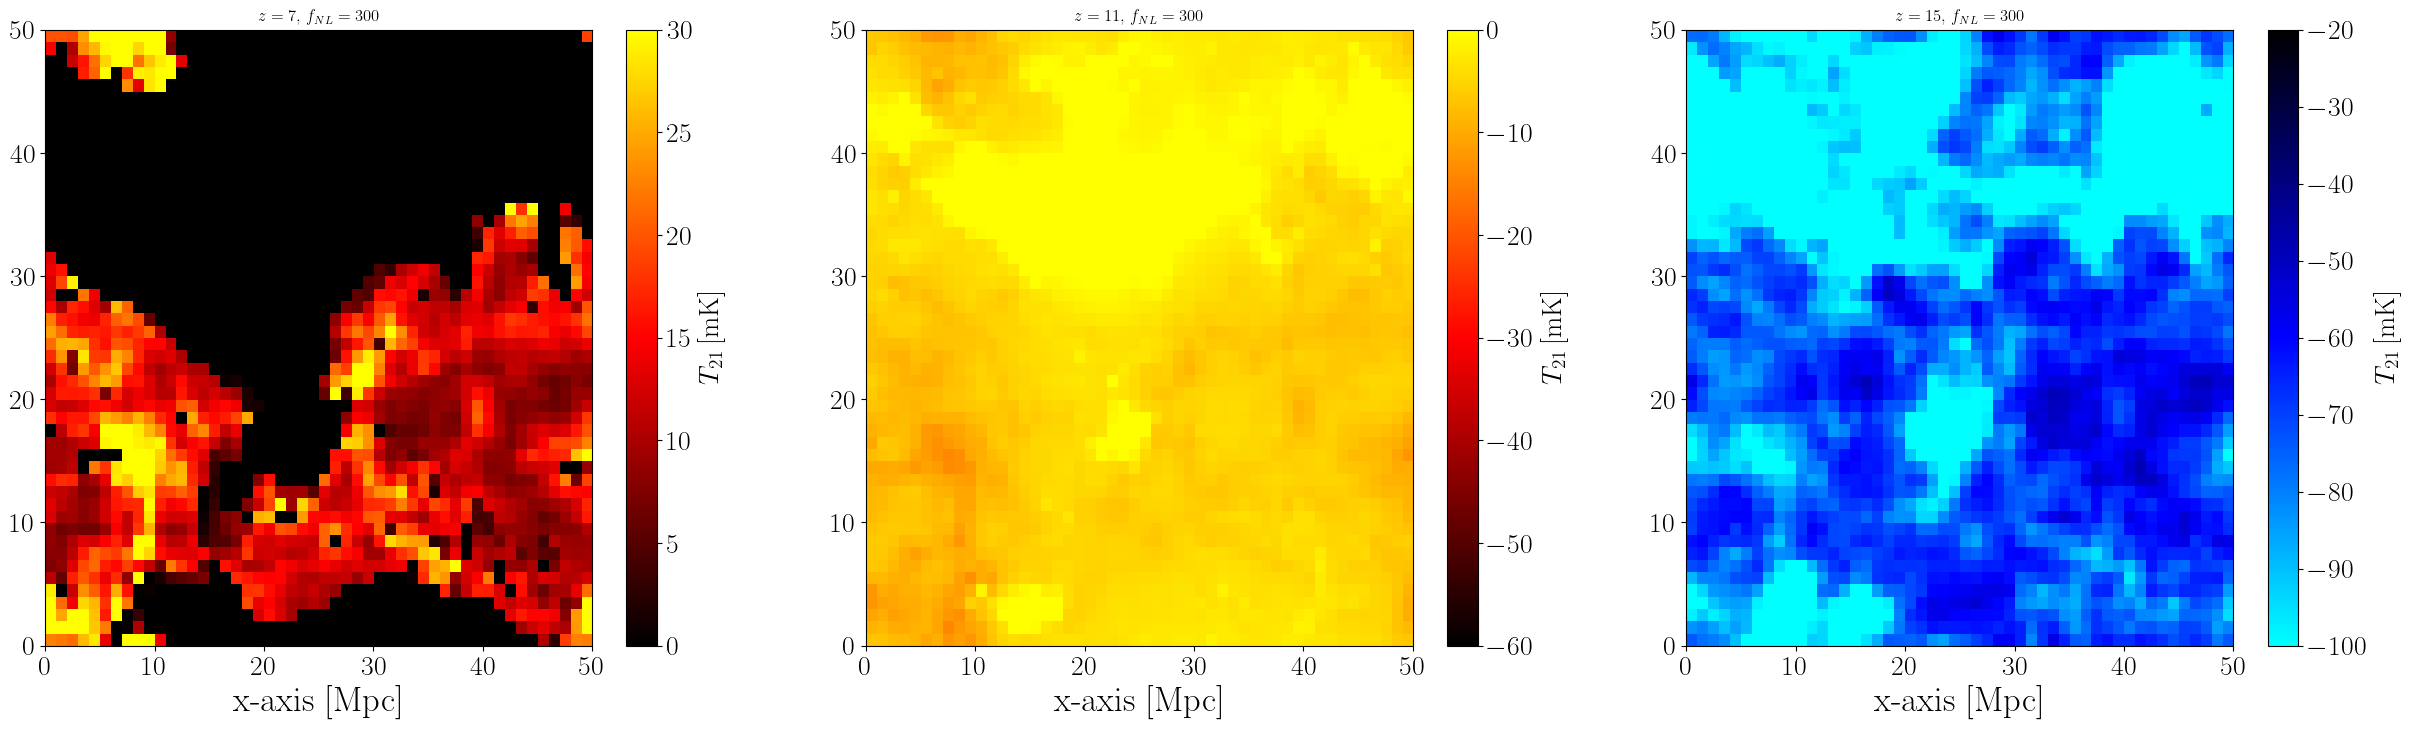

In [13]:
plot_boxes(30, 10, -300.)
plot_boxes(30, 10, -100.)
plot_boxes(30, 10, -50.)
# plot_boxes(150, 50, -10.)
plot_boxes(30, 10, 0.)
# plot_boxes(150, 50, 10.)
plot_boxes(30, 10, 50.)
plot_boxes(30, 10, 100.)
plot_boxes(30, 10, 300.)